In [40]:

from mGST.low_level_jit import cost_function_jax_mps
from mGST.utility_functions_comparisons import get_compressed_rep_from_mgst_output

from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, create_4q_gst_config
from mGST.visualization import plot_wall_time

import jax.numpy as jnp

backend = "iqmfakeapollo"
data_path = "../data/"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Goal:

1. Verify the complexity of the cost function as a function of the system size. From the theory, this should be $\mathcal{O}(2^{3N})$
2. Verify the complexity of the gradient as a function of the cost function cost ($C$). From the theory this should be $\mathcal{O}(C)$. Furthermore, the Baur-Strassen theorem gaurantees this is bounded by a low factor: $C(\nabla f) \leq 5 C(f)$.
3. Verify the complexity of the Hessian-vector product as a function of the cost function cost ($C$). Again, this should be linear with the cost funciton cost: $\mathcal{O}(C)$.
4. Check the dependence of each of these for the different operators. There seems to be a dependance with the input dimension (at least for higher order derivatives). Check this when using a `lambda` funciton and when not.

# Tensor generation

In [19]:
# fixed kraus rank to really the dependence in the system size dimension
kraus_rank = 1
# In general, the max kraus rank would be dim**2 with dim = 2**n_qubits

In [ ]:
# First using the JAX compilation with smaller qubits to see if this helps
dim_1q = 2

Q1_GST = GSTConfiguration(
    qubit_layouts=[[0]],
    gate_set="1QXYI",
    num_circuits=100,
    shots=1000,
    rank=kraus_rank,
)

kraus_tensor_mgst_1q, kraus_mgst_1q, povm_mgst_1q, state_mgst_1q, prob_matrix_1q, indices_list_1q = get_full_mgst_parameters_from_configuration(
    Q1_GST, backend, only_jax_variables=True
)

kraus_tensor_1q_target, povm_psd_1q_target, state_psd_1q_target = get_compressed_rep_from_mgst_output(kraus_mgst_1q, povm_mgst_1q, state_mgst_1q, kraus_rank=kraus_rank, state_rank=dim_1q, povm_rank=dim_1q)


2025-10-02 15:37:36,481 - iqm.benchmarks.logging_config - INFO - Now generating 100 random GST circuits...
2025-10-02 15:37:36,502 - iqm.benchmarks.logging_config - INFO - Will transpile all 100 circuits according to fixed physical layout
2025-10-02 15:37:36,502 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-10-02 15:37:36,621 - iqm.benchmarks.logging_config - INFO - Submitting batch with 100 circuits corresponding to qubits [0]
2025-10-02 15:37:36,622 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-10-02 15:37:36,877 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [ ]:
dim_2q = 2**2

Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYCZ",
    num_circuits=800,
    shots=1000,
    rank=kraus_rank,
)

kraus_tensor_mgst_2q, kraus_mgst_2q, povm_mgst_2q, state_mgst_2q, prob_matrix_2q, indices_list_2q = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend, only_jax_variables=True
)

kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target = get_compressed_rep_from_mgst_output(kraus_mgst_2q, povm_mgst_2q, state_mgst_2q, kraus_rank=kraus_rank, state_rank=dim_2q, povm_rank=dim_2q)

2025-10-02 15:43:03,243 - iqm.benchmarks.logging_config - INFO - Now generating 800 random GST circuits...
2025-10-02 15:43:03,724 - iqm.benchmarks.logging_config - INFO - Will transpile all 800 circuits according to fixed physical layout
2025-10-02 15:43:03,725 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-10-02 15:43:05,026 - iqm.benchmarks.logging_config - INFO - Submitting batch with 800 circuits corresponding to qubits [0, 1]
2025-10-02 15:43:05,027 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-10-02 15:43:05,097 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [30]:
dim_3q = 2**3

Q3_GST = GSTConfiguration(
    qubit_layouts=[[0,1,3]],
    gate_set="3QXYCZ",
    num_circuits=1000,
    shots=1000,
    rank=kraus_rank,
)

kraus_tensor_mgst_3q, kraus_mgst_3q, povm_mgst_3q, state_mgst_3q, prob_matrix_3q, indices_list_3q = get_full_mgst_parameters_from_configuration(
    Q3_GST, backend, only_jax_variables=True
)

kraus_tensor_3q_target, povm_psd_3q_target, state_psd_3q_target = get_compressed_rep_from_mgst_output(kraus_mgst_3q, povm_mgst_3q, state_mgst_3q, kraus_rank=kraus_rank, state_rank=dim_3q, povm_rank=dim_3q)

2025-10-02 16:03:32,716 - iqm.benchmarks.logging_config - INFO - Now generating 1000 random GST circuits...
2025-10-02 16:03:32,927 - iqm.benchmarks.logging_config - INFO - Will transpile all 1000 circuits according to fixed physical layout
2025-10-02 16:03:32,927 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-10-02 16:03:35,125 - iqm.benchmarks.logging_config - INFO - Submitting batch with 1000 circuits corresponding to qubits [0, 1, 3]
2025-10-02 16:03:35,127 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-10-02 16:03:35,182 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [20]:
dim_4q = 2**4
Q4_GST = create_4q_gst_config(kraus_rank=kraus_rank)

kraus_tensor_mgst_4q, kraus_mgst_4q, povm_mgst_4q, state_mgst_4q, prob_matrix_4q, indices_list_4q = get_full_mgst_parameters_from_configuration(
    Q4_GST, backend, only_jax_variables=True
)

kraus_tensor_4q_target, povm_psd_4q_target, state_psd_4q_target = get_compressed_rep_from_mgst_output(kraus_mgst_4q, povm_mgst_4q, state_mgst_4q, kraus_rank=kraus_rank, state_rank=dim_4q, povm_rank=dim_4q)

2025-10-02 15:47:39,154 - iqm.benchmarks.logging_config - INFO - Now generating 2000 random GST circuits...
2025-10-02 15:47:39,814 - iqm.benchmarks.logging_config - INFO - Will transpile all 2000 circuits according to fixed physical layout
2025-10-02 15:47:39,815 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-10-02 15:47:43,156 - iqm.benchmarks.logging_config - INFO - Submitting batch with 2000 circuits corresponding to qubits [0, 1, 3, 4]
2025-10-02 15:47:43,159 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-10-02 15:47:43,214 - iqm.benchmarks.logging_config - INFO - Retrieving all counts


In [88]:
input_1q = {
    "kraus_tensor": kraus_tensor_1q_target,
    "povm_psd": povm_psd_1q_target,
    "state_psd": state_psd_1q_target,
    "prob_matrix": prob_matrix_1q,
    "indices_list": indices_list_1q,
}

input_2q = {
    "kraus_tensor": kraus_tensor_2q_target,
    "povm_psd": povm_psd_2q_target,
    "state_psd": state_psd_2q_target,
    "prob_matrix": prob_matrix_2q,
    "indices_list": indices_list_2q,
}

input_3q = {
    "kraus_tensor": kraus_tensor_3q_target,
    "povm_psd": povm_psd_3q_target,
    "state_psd": state_psd_3q_target,
    "prob_matrix": prob_matrix_3q,
    "indices_list": indices_list_3q,
}

input_4q = {
    "kraus_tensor": kraus_tensor_4q_target,
    "povm_psd": povm_psd_4q_target,
    "state_psd": state_psd_4q_target,
    "prob_matrix": prob_matrix_4q,
    "indices_list": indices_list_4q,   
}

print(len(indices_list_1q[-1]), len(indices_list_2q[-1]), len(indices_list_3q[-1]), len(indices_list_4q[-1]))
print(len(indices_list_1q), len(indices_list_2q), len(indices_list_3q), len(indices_list_4q))
print(prob_matrix_1q.shape, prob_matrix_2q.shape, prob_matrix_3q.shape, prob_matrix_4q.shape)

prob_matrices = [prob_matrix_1q, prob_matrix_2q, prob_matrix_3q, prob_matrix_4q]
num_sequences_list = [matrix.shape[1] for matrix in prob_matrices]
num_povms = [matrix.shape[0] for matrix in prob_matrices]

14 14 14 14
100 800 1000 2000
(2, 100) (4, 800) (8, 1000) (16, 2000)


In [92]:
num_povms, num_sequences_list

([2, 4, 8, 16], [100, 800, 1000, 2000])

# Cost function

First, we run once each of them to let it compile

In [ ]:
cost_1q = cost_function_jax_mps(jit=True, **input_1q)
cost_2q = cost_function_jax_mps(jit=True, **input_2q)
cost_3q = cost_function_jax_mps(jit=True, **input_3q)
cost_4q = cost_function_jax_mps(jit=True, **input_4q)

In [ ]:
# Store timing result in a variable
timing_1q = %timeit -o cost_function_jax_mps(jit=True, **input_1q)
timing_2q = %timeit -o cost_function_jax_mps(jit=True, **input_2q)
timing_3q = %timeit -o cost_function_jax_mps(jit=True, **input_3q)
timing_4q = %timeit -o cost_function_jax_mps(jit=True, **input_4q)

2.38 ms ± 56 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
28.1 ms ± 1.21 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
38.6 ms ± 1.85 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
203 ms ± 1.04 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [94]:
timings_cost_fn = [timing_1q, timing_2q, timing_3q, timing_4q]
tuples_cost_fn = [(time.average, time.stdev) for time in timings_cost_fn]
tuples_cost_fn_scaled = [(time.average/(num_seq), time.stdev/(num_seq)) for time, num_seq in zip(timings_cost_fn, num_sequences_list)]
# tuples_cost_fn_scaled = [(time.average/(num_seq * num_povm), time.stdev/(num_seq * num_povm)) for time, num_seq, num_povm in zip(timings_cost_fn, num_sequences_list, num_povms)]

here


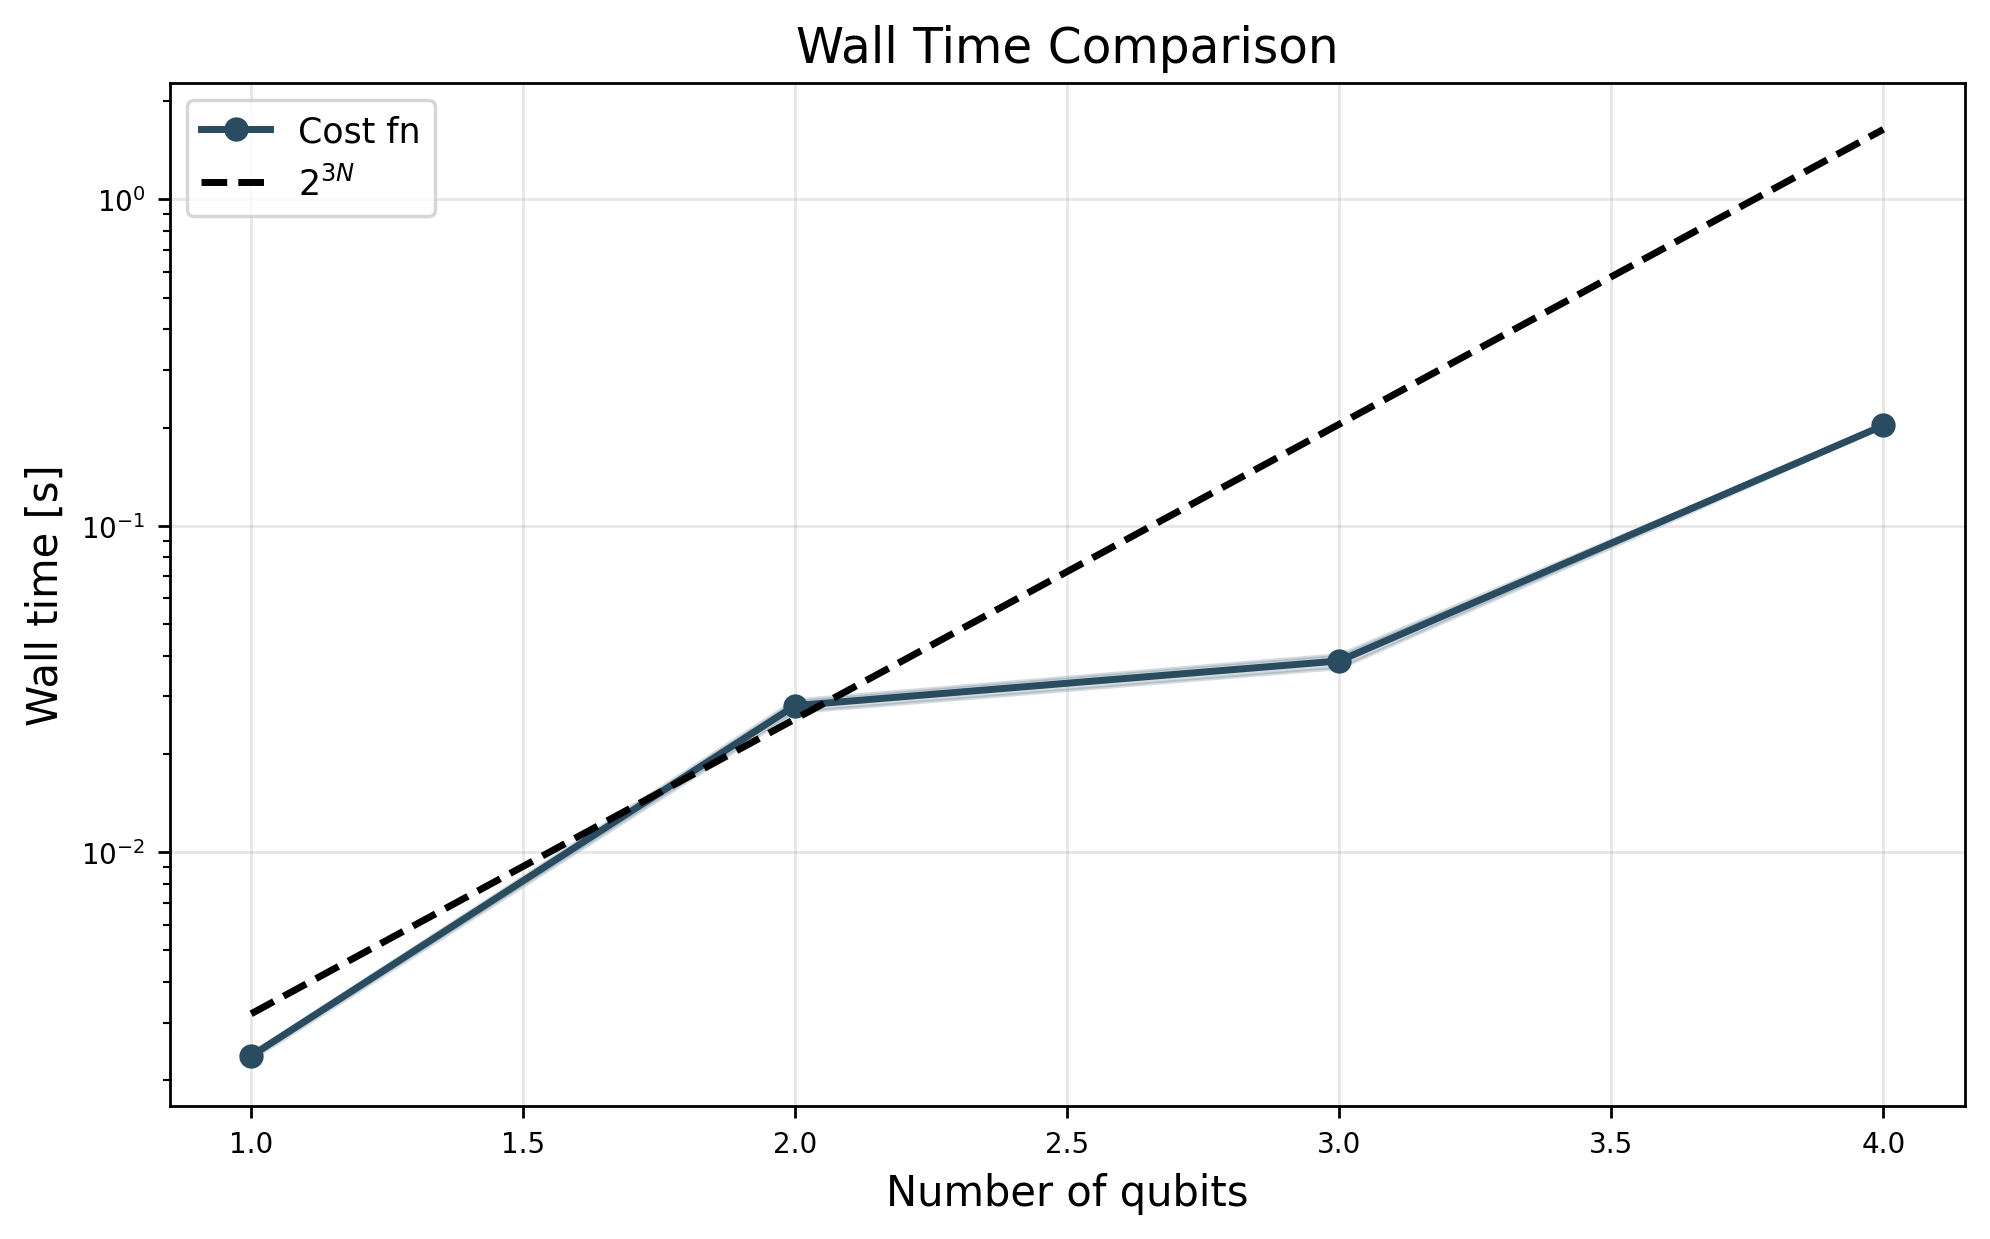

In [126]:
cost_fn_times = {
    "Cost fn": tuples_cost_fn,
    # "Cost fn (scaled by num sequences)": tuples_cost_fn_scaled,
}

x_data = jnp.arange(1, 5)
y_data = 2**(3 * x_data) * 4e-4
comparison_data = {
    r"$2^{3N}$": (x_data, y_data)
}

num_qubits = [1, 2, 3, 4]

plot_wall_time(cost_fn_times, num_qubits, logscale="y", comparison_data=comparison_data)